In [1]:
# --- Step 1: Import Libraries and Load Dataset ---
import nltk
import pandas as pd
import random
from nltk.corpus import movie_reviews
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier

nltk.download('movie_reviews')
nltk.download('punkt')
nltk.download('stopwords')

# Load and shuffle movie reviews
documents = []
for category in movie_reviews.categories():
    for fileid in movie_reviews.fileids(category):
        review_text = movie_reviews.raw(fileid)
        documents.append((review_text, category))

random.shuffle(documents)

df = pd.DataFrame(documents, columns=['review_text', 'label'])
print(df.sample(5), "\n")

# --- Step 2: Preprocessing Function ---
stop_words = set(stopwords.words('english'))

def preprocess(text):
    tokens = word_tokenize(text.lower())
    cleaned = [word for word in tokens if word.isalpha() and word not in stop_words]
    return ' '.join(cleaned)

# Apply preprocessing to all reviews
df['cleaned_text'] = df['review_text'].apply(preprocess)

# --- Step 3: TF-IDF Vectorization ---
tfidf_vectorizer = TfidfVectorizer()
x = tfidf_vectorizer.fit_transform(df['cleaned_text'])
y = df['label']

# --- Step 4: Train/Test Split ---
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# --- Step 5: Model Definitions and Training ---
models = {
    "Logistic Regression": LogisticRegression(C=1.0, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=10, min_samples_split=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=10),
    "SVM": SVC(C=1.0, kernel='linear'),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": MultinomialNB(alpha=0.5),
    # "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5)
}

trained_models = {}
print("\n🔍 Classification Reports:\n")
for name, model in models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    print(f"{name} Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    trained_models[name] = model


[nltk_data] Downloading package movie_reviews to
[nltk_data]     /home/itachi_uchiha/nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /home/itachi_uchiha/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/itachi_uchiha/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


                                            review_text label
67    stendhal's syndrome : a condition where , in t...   pos
1858  vannesa kensington : `austin , do you smoke af...   pos
120   written by john grisham and robert altman ( as...   pos
1027  it used to be that not just anyone could becom...   neg
135   what do you get when you combine clueless and ...   pos 


🔍 Classification Reports:

Logistic Regression Accuracy: 0.8350
Decision Tree Accuracy: 0.6825
Random Forest Accuracy: 0.7800
SVM Accuracy: 0.8425
KNN Accuracy: 0.6500
Naive Bayes Accuracy: 0.7975


In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,classification_report


print("\n📊 Detailed Evaluation Metrics:\n")
for name, model in models.items():
    y_pred = model.predict(x_test)

    # print(f"{name} Accuracy       : {accuracy_score(y_test, y_pred):.4f}")
    # print(f"{name} precision       : {precision_score(y_test, y_pred,pos_label='pos'):.4f}")
    # print(f"{name} recall       : {recall_score(y_test, y_pred,pos_label='pos'):.4f}")
    # print(f"{name} rf1-score      : {f1_score(y_test, y_pred,pos_label='pos'):.4f}\n")
    print(f"------{name}------\n")
    print(classification_report(y_test, y_pred, target_names=['neg', 'pos']))
    trained_models[name] = model



📊 Detailed Evaluation Metrics:

------Logistic Regression------

              precision    recall  f1-score   support

         neg       0.87      0.79      0.83       202
         pos       0.80      0.88      0.84       198

    accuracy                           0.83       400
   macro avg       0.84      0.84      0.83       400
weighted avg       0.84      0.83      0.83       400

------Decision Tree------

              precision    recall  f1-score   support

         neg       0.70      0.64      0.67       202
         pos       0.66      0.73      0.69       198

    accuracy                           0.68       400
   macro avg       0.68      0.68      0.68       400
weighted avg       0.68      0.68      0.68       400

------Random Forest------

              precision    recall  f1-score   support

         neg       0.77      0.80      0.79       202
         pos       0.79      0.76      0.77       198

    accuracy                           0.78       400
   macro


📊 Confusion Matrices for All Models:

Logistic Regression:
[[159  43]
 [ 23 175]]



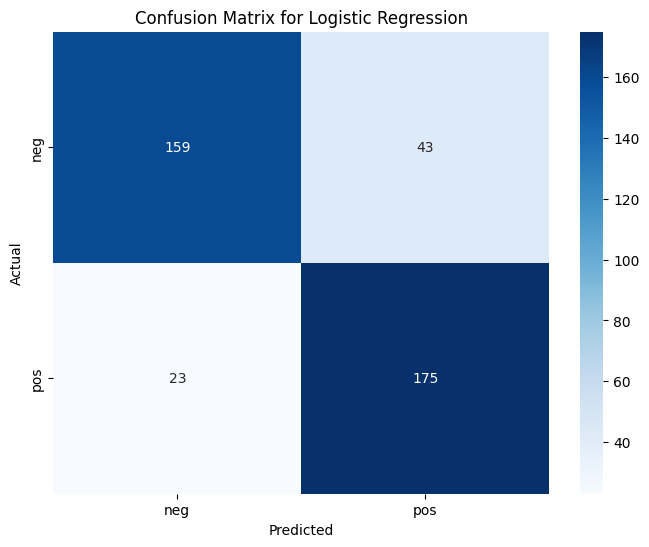

Decision Tree:
[[129  73]
 [ 54 144]]



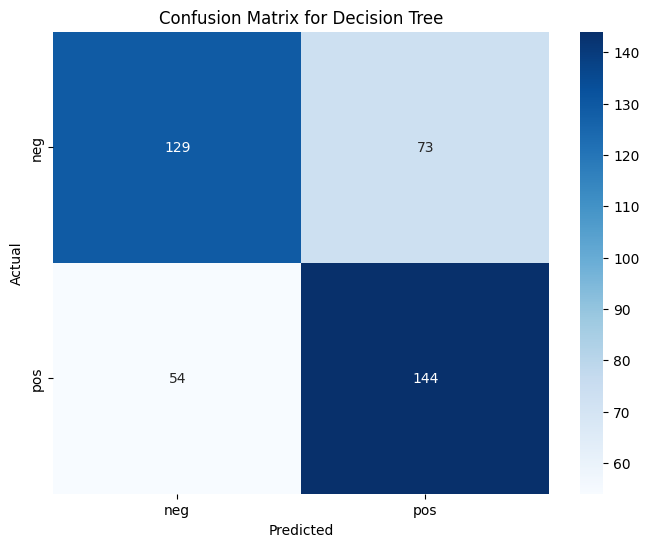

Random Forest:
[[161  41]
 [ 47 151]]



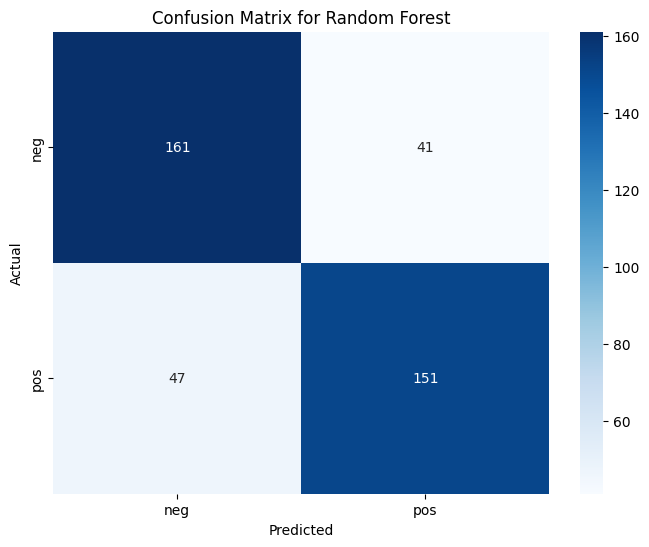

SVM:
[[162  40]
 [ 23 175]]



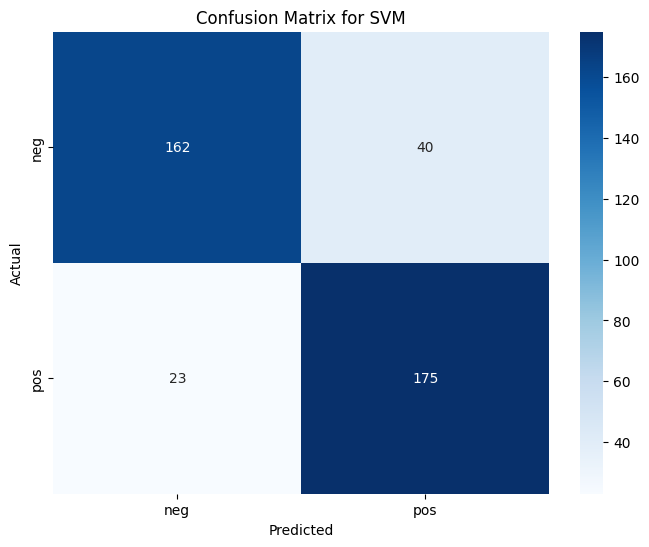

KNN:
[[119  83]
 [ 57 141]]



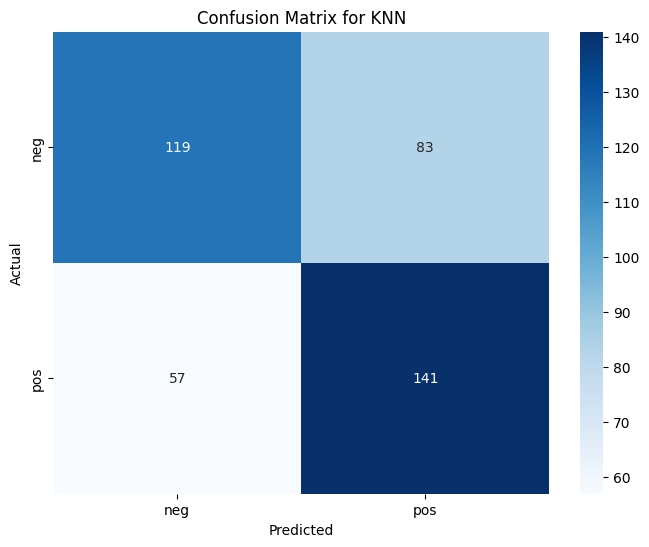

Naive Bayes:
[[157  45]
 [ 36 162]]



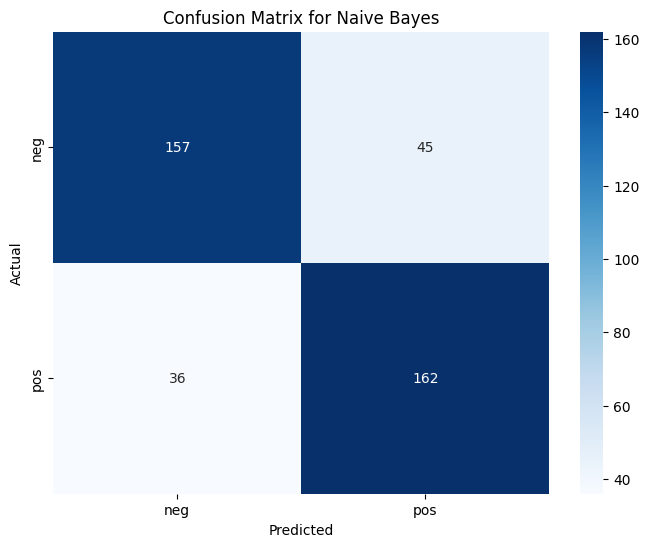

In [4]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

print("\n📊 Confusion Matrices for All Models:\n")
for name, model in models.items():
    y_pred = model.predict(x_test)
    cm = confusion_matrix(y_test, y_pred)
    print(f"{name}:\n{cm}\n")
    
    import matplotlib.pyplot as plt

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['neg', 'pos'], yticklabels=['neg', 'pos'])
    plt.title(f"Confusion Matrix for {name}")
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

In [ ]:
# Interface for predicting from all models
def predict_sentiment_all_models(review_text):
    cleaned = preprocess(review_text)
    vectorized = tfidf_vectorizer.transform([cleaned])
    
    print(f"\n📢 Input Review: {review_text}")
    for name, model in trained_models.items():
        prediction = model.predict(vectorized)[0]
        emoji = "😊" if prediction == 'pos' else "😞"
        print(f"{name}: {prediction.upper()} {emoji}")

# CLI loop
while True:
    user_input = input("\nEnter a review (or type 'exit' to quit):\n")
    if user_input.lower() == 'exit':
        break
    predict_sentiment_all_models(user_input)





📢 Input Review: what a fantastic movie
Logistic Regression: POS 😊
Decision Tree: POS 😊
Random Forest: POS 😊
SVM: POS 😊
KNN: POS 😊
Naive Bayes: POS 😊
Gradient Boosting: POS 😊

📢 Input Review: not a bad movie average film
Logistic Regression: NEG 😞
Decision Tree: NEG 😞
Random Forest: POS 😊
SVM: NEG 😞
KNN: NEG 😞
Naive Bayes: NEG 😞
Gradient Boosting: NEG 😞
